# Dataset Tester
Notebook to test classification using the generated datasets


Mario Castro


Prueba con info dataset

In [28]:
import pandas as pd

In [29]:
path = r"../Data/raw"

original_info_df = pd.read_csv(f"{path}/INFO_AUG.csv")

In [30]:
original_info_df.nunique()

client_utterance       100
clinician_utterance    200
behavior_code_1          2
dtype: int64

In [31]:
generated_info_df = pd.read_csv('generated_dataset_info.csv')

In [32]:
generated_info_df.nunique()

client_utterance       194
clinician_utterance    200
behavior_code_1          2
dtype: int64

In [33]:
generated_info_df.isna().sum()

client_utterance       0
clinician_utterance    0
behavior_code_1        0
dtype: int64

In [34]:
generated_info_df['input'] = generated_info_df['client_utterance'] + ' ' + generated_info_df['clinician_utterance']
original_info_df['input'] = original_info_df['client_utterance'] + ' ' + original_info_df['clinician_utterance']


In [35]:
generated_info_df['input'].head()

0    ¡Estoy harto de que me digan qué hacer! Me sie...
1    Me siento abrumado con todas estas restriccion...
2    No necesito dejar de fumar, estoy bien y no te...
3    No sé cómo manejar mi ira y mis estudios, ya n...
4    He estado usando marihuana varias veces, pero ...
Name: input, dtype: str

In [36]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MasterHDXD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
stop_words = set(stopwords.words('spanish'))

# basic preprocessing
generated_info_df['input'] = generated_info_df['input'].str.lower()
original_info_df['input'] = original_info_df['input'].str.lower()

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

generated_info_df['input'] = generated_info_df['input'].apply(remove_stopwords)
original_info_df['input'] = original_info_df['input'].apply(remove_stopwords)

In [38]:
generated_info_df['input'].head()

0    ¡estoy harto digan hacer! siento agotado tiemp...
1    siento abrumado todas restricciones presión ma...
2    necesito dejar fumar, bien tiempo eso. consumo...
3    sé cómo manejar ira estudios, aguanto más. uso...
4    usando marihuana varias veces, siempre vuelvo ...
Name: input, dtype: str

## Model

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix





--- LogisticRegression ---
              precision    recall  f1-score   support

          GI       0.64      0.59      0.61       100
          PE       0.62      0.67      0.64       100

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200



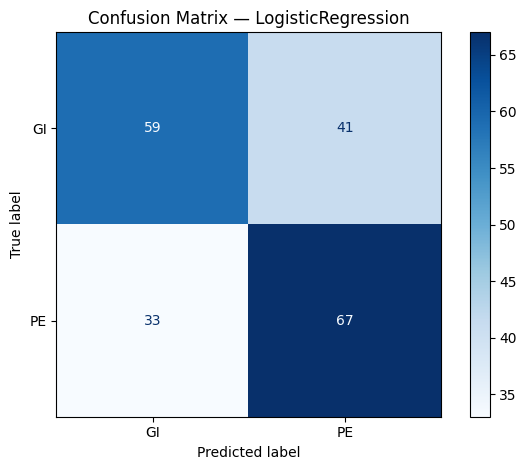


--- ComplementNB ---
              precision    recall  f1-score   support

          GI       0.63      0.62      0.62       100
          PE       0.62      0.63      0.63       100

    accuracy                           0.62       200
   macro avg       0.63      0.62      0.62       200
weighted avg       0.63      0.62      0.62       200



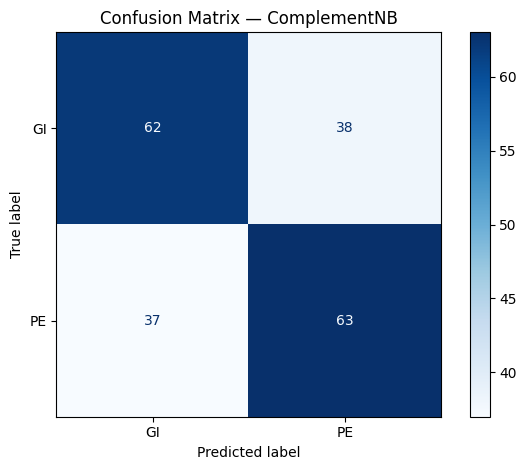


--- LinearSVC ---
              precision    recall  f1-score   support

          GI       0.58      0.58      0.58       100
          PE       0.58      0.58      0.58       100

    accuracy                           0.58       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.58      0.58      0.58       200



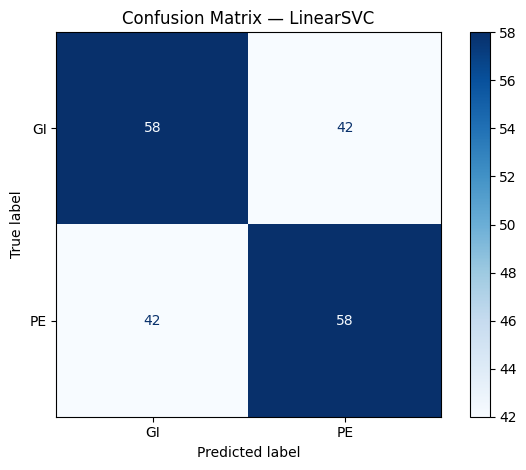

In [48]:
X_train = generated_info_df['input']
y_train = generated_info_df['behavior_code_1']
X_test = original_info_df['input']
y_test = original_info_df['behavior_code_1']
# Fit vectorizer once
vectorizer = TfidfVectorizer(strip_accents='unicode', ngram_range=(1, 2), max_features=50000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)  # transform only, never fit on test

# Define models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "ComplementNB": ComplementNB(),
    "LinearSVC": LinearSVC(),
}

fitted_models = []

# Train each model and collect CV scores
for name, clf in models.items():
    clf.fit(X_train_vec, y_train)
    fitted_models.append((name, clf))

# Classification report for each model on test data
for name, clf in fitted_models:
    y_pred = clf.predict(X_test_vec)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()